In [1]:
import numpy as np
import json
import csv
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import matplotlib.font_manager as font_manager
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Plot outlet sharing distribution 1D (Fig. 2 A/B/C)

In [2]:
edgelist = pd.read_csv('./data/shares_pseudo.csv', dtype = str)
edgelist = edgelist.drop_duplicates(subset = ['tweet_id'])

In [3]:
user_embedding = './data/embedding_pseudo.csv'

user_emb_df = pd.read_csv(user_embedding, dtype = str)
user_emb_df = user_emb_df.set_index('user')

user_list = list(edgelist.user)
pos_dict = user_emb_df.T.to_dict('list')

/var/folders/_p/7vwplj9155x7q1tghmrxfnlr0000gp/T/ipykernel_14497/1104390507.py:7: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  pos_dict = user_emb_df.T.to_dict('list')


In [4]:
pos_list_x = []
pos_list_y = []

ct = 0
ne_ct=0

for user_id in tqdm(user_list):
    if user_id in pos_dict.keys():
        pos_list_x.append(pos_dict[user_id][0])
        pos_list_y.append(pos_dict[user_id][1])
        ct +=1
    else:
        pos_list_x.append('not_embedded')
        pos_list_y.append('not_embedded')
        ne_ct +=1

edgelist['x'] = pos_list_x
edgelist['y'] = pos_list_y

100%|██████████████████████████████| 542764/542764 [00:00<00:00, 1532279.75it/s]


In [5]:
def plot_outlet_distribution_1D(outlet, edgelist, follower_color, follower_alpha, hist_alpha, density=True):
    
    edgelist = edgelist[edgelist['outlet'] == outlet]
    
    FOLLOWER_COLOR = follower_color
    FOLLOWER_ALPHA = follower_alpha
    STORY_COLOR_MEAN = "red"    
    
    title = outlet + ': Outlet sharing distribution'
    
    x = list(edgelist['x'])

    x = [float(s) for s in x if s!='not_embedded']
    plt.ylim(0,.9)
    plt.xlim(-3,3)
    plt.yticks(color='w')
    plt.xticks([-3,-2,-1,0,1,2,3], ['','','',0,'','',''])
    plt.hist(x, color = follower_color, alpha = follower_alpha, edgecolor = 'black', bins = 50, density = True)
    plt.grid()
    plt.xlabel('Left-right',fontsize = 17,fontdict = {'weight':'bold'})
    plt.ylabel('Outlet sharing distribution (1D)',fontsize = 17,fontdict = {'weight':'bold'})
    plt.title(outlet, fontsize = 17,fontdict = {'weight':'bold'})
    plt.savefig('./' + outlet + '_1D.pdf', bbox_inches = 'tight')
    plt.show()
    plt.close()
    
    return None    


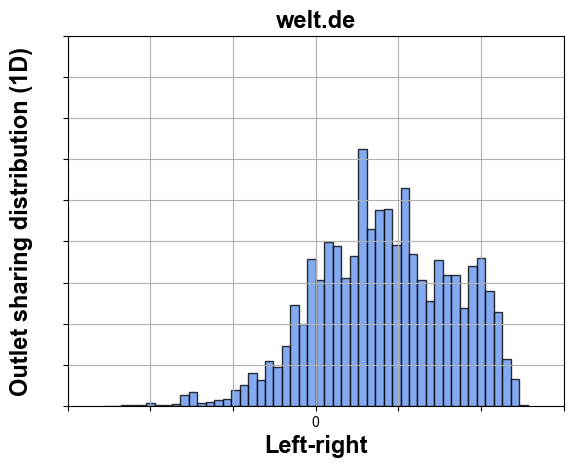

In [6]:
plot_outlet_distribution_1D('welt.de',
                    edgelist,
                    #partycol_list,
                    follower_color='#6495ED',
                    follower_alpha=.8,
                    hist_alpha=.8,
                    density=True)